In [26]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score, f1_score, precision_recall_curve
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
X_train = pd.read_csv('..\\data\\processed\\X_train.csv')
X_test  = pd.read_csv('..\\data\\processed\\X_test.csv')
y_train = pd.read_csv('..\\data\\processed\\y_train.csv').squeeze()  
y_test  = pd.read_csv('..\\data\\processed\\y_test.csv').squeeze()

In [28]:
print("Train shape:", X_train.shape)
print("Test shape: ", X_test.shape)
print("\nClass distribution (train):")
print(y_train.value_counts(normalize=True).round(3))

Train shape: (1048236, 16)
Test shape:  (262059, 16)

Class distribution (train):
ArrDel15
0.0    0.802
1.0    0.198
Name: proportion, dtype: float64


In [29]:
cat_features = ['DayOfWeek', 'dep_period', 'season',
                'Origin', 'Dest', 'Reporting_Airline']

for col in cat_features:
    X_train[col] = X_train[col].astype(str)
    X_test[col]  = X_test[col].astype(str)

In [30]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos

print(f"Not delayed: {neg:,}")
print(f"Delayed:     {pos:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

Not delayed: 840,198
Delayed:     208,038
scale_pos_weight: 4.04


In [31]:
train_pool = Pool(X_train, y_train, cat_features=cat_features)
test_pool  = Pool(X_test,  y_test,  cat_features=cat_features)

model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='AUC',
    early_stopping_rounds=50,   
    random_seed=42,
    verbose=100                 
)

model.fit(train_pool, eval_set=test_pool)

0:	test: 0.6156469	best: 0.6156469 (0)	total: 857ms	remaining: 28m 32s
100:	test: 0.6358928	best: 0.6358928 (100)	total: 1m 12s	remaining: 22m 37s
200:	test: 0.6393006	best: 0.6393006 (200)	total: 2m 22s	remaining: 21m 14s
300:	test: 0.6406972	best: 0.6406972 (300)	total: 3m 30s	remaining: 19m 48s
400:	test: 0.6419488	best: 0.6419583 (399)	total: 4m 45s	remaining: 18m 57s
500:	test: 0.6426206	best: 0.6426206 (500)	total: 6m	remaining: 17m 58s
600:	test: 0.6430336	best: 0.6430410 (597)	total: 7m 15s	remaining: 16m 54s
700:	test: 0.6434391	best: 0.6434393 (697)	total: 8m 30s	remaining: 15m 45s
800:	test: 0.6437139	best: 0.6437139 (800)	total: 9m 45s	remaining: 14m 36s
900:	test: 0.6440228	best: 0.6440228 (900)	total: 11m 3s	remaining: 13m 29s
1000:	test: 0.6441949	best: 0.6441949 (1000)	total: 12m 22s	remaining: 12m 20s
1100:	test: 0.6443425	best: 0.6443425 (1100)	total: 13m 39s	remaining: 11m 9s
1200:	test: 0.6444522	best: 0.6444693 (1177)	total: 14m 58s	remaining: 9m 57s
1300:	test: 0.

Best threshold: 0.47
Best F1:        0.3802


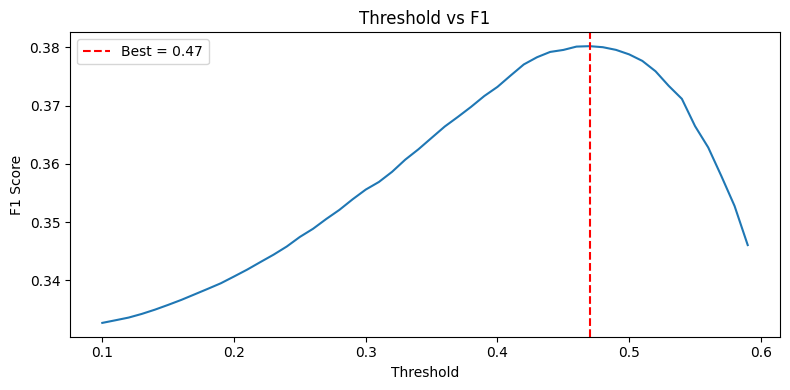

In [32]:
# Get predicted probabilities — NOT hard 0/1 predictions yet
y_proba = model.predict_proba(X_test)[:, 1]

# Scan thresholds and find the one maximizing F1
thresholds = np.arange(0.1, 0.6, 0.01)
f1_scores  = [f1_score(y_test, (y_proba >= t).astype(int)) for t in thresholds]

best_threshold = thresholds[np.argmax(f1_scores)]
print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1:        {max(f1_scores):.4f}")

# Plot threshold vs F1
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best = {best_threshold:.2f}')
plt.xlabel('Threshold')
plt.ylabel('F1 Score')
plt.title('Threshold vs F1')
plt.legend()
plt.tight_layout()
plt.show()

=== Classification Report ===
              precision    recall  f1-score   support

     On Time       0.87      0.56      0.68    209963
     Delayed       0.27      0.66      0.38     52096

    accuracy                           0.58    262059
   macro avg       0.57      0.61      0.53    262059
weighted avg       0.75      0.58      0.62    262059

ROC-AUC: 0.6449


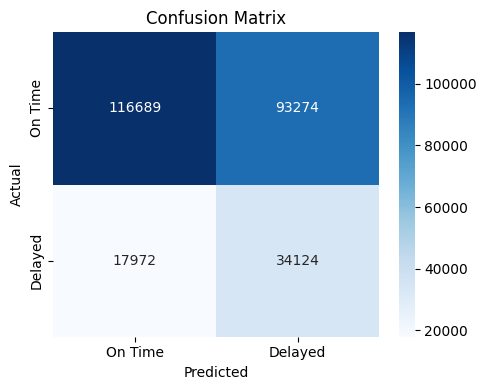

In [33]:
y_pred = (y_proba >= best_threshold).astype(int)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=['On Time', 'Delayed']))

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On Time', 'Delayed'],
            yticklabels=['On Time', 'Delayed'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

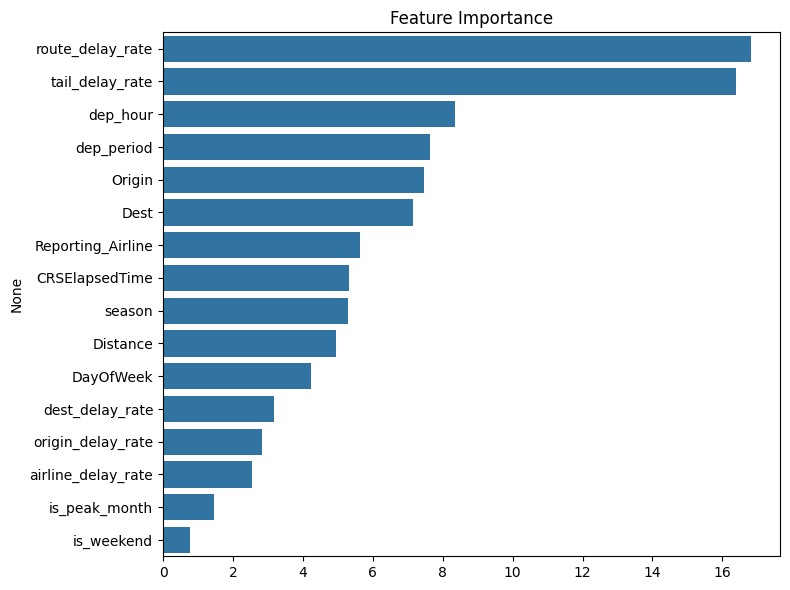

In [34]:
feat_imp = pd.Series(model.get_feature_importance(),
                     index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

Best Model:   CatBoost 

AUC:          0.644 

Delayed F1:   0.38 

Threshold:    0.47 

Limitation:   Ceiling imposed by absence of weather data.
              Weather accounts for ~40% of real-world delays
              and is not present in the BTS dataset.